# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import logging
import sys
sys.path.append('/Users/huez/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [3]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [4]:
testdata = np.load('/Users/huez/mlpractical/data/emnist-test.npz')
print(testdata.files)
inputs = testdata['inputs']
targets = testdata['targets']
print(inputs.shape)
print(targets.shape)
print(inputs.dtype)
print(targets.dtype)
print(len(np.unique(targets)))
# print(testdata.keys())

['inputs', 'targets']
(15800, 28, 28)
(15800,)
uint8
uint8
47


In [5]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 3.7s to complete
    error(train)=7.72e-01, acc(train)=7.60e-01, error(valid)=7.87e-01, acc(valid)=7.58e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 3: 3.7s to complete
    error(train)=5.02e-01, acc(train)=8.36e-01, error(valid)=5.56e-01, acc(valid)=8.19e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 3.6s to complete
    error(train)=4.68e-01, acc(train)=8.43e-01, error(valid)=5.45e-01, acc(valid)=8.22e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 3.7s to complete
    error(train)=4.46e-01, acc(train)=8.42e-01, error(valid)=5.39e-01, acc(valid)=8.17e-01


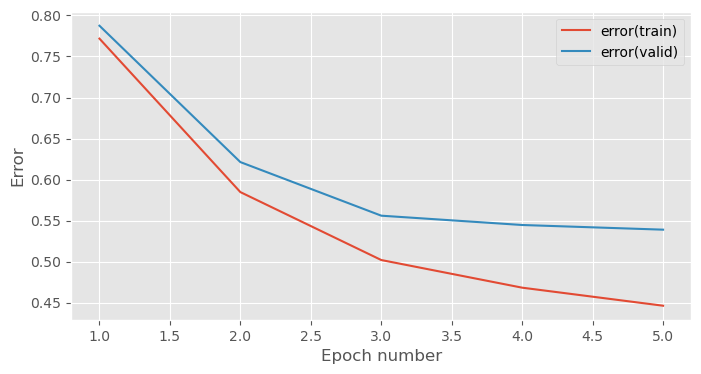

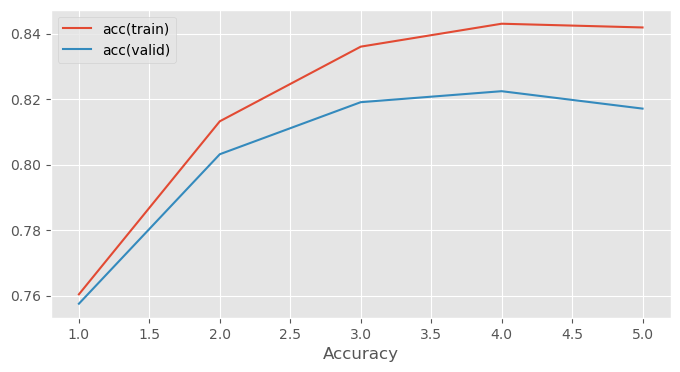

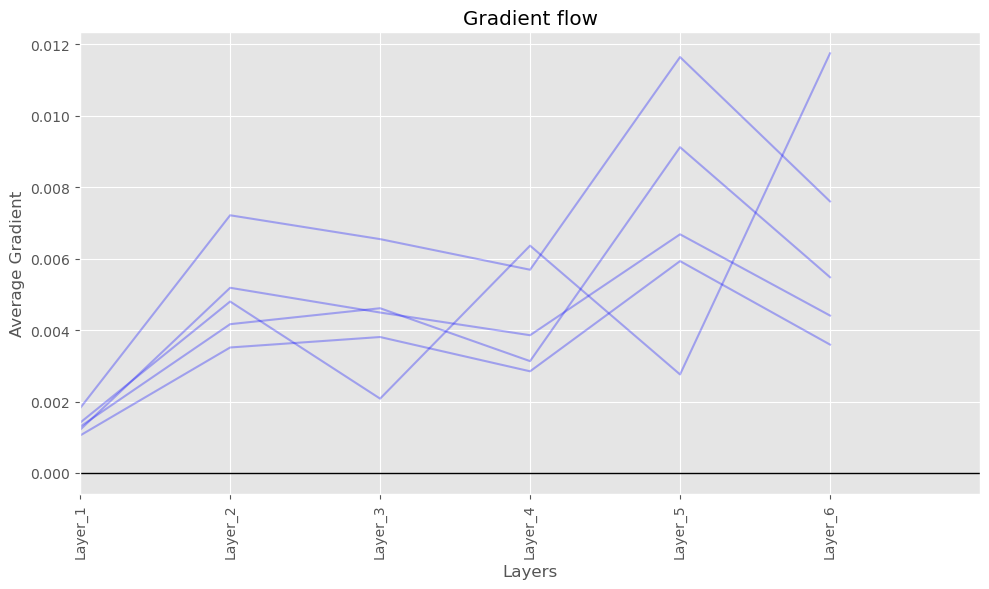

In [6]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 5.4s to complete
    error(train)=3.85e+00, acc(train)=2.14e-02, error(valid)=3.85e+00, acc(valid)=2.09e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 5.1s to complete
    error(train)=3.85e+00, acc(train)=2.12e-02, error(valid)=3.85e+00, acc(valid)=2.16e-02


...

Epoch 3: 4.9s to complete
    error(train)=3.85e+00, acc(train)=2.11e-02, error(valid)=3.85e+00, acc(valid)=2.13e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 5.0s to complete
    error(train)=3.85e+00, acc(train)=2.13e-02, error(valid)=3.85e+00, acc(valid)=2.28e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 4.7s to complete
    error(train)=3.85e+00, acc(train)=2.14e-02, error(valid)=3.85e+00, acc(valid)=2.09e-02


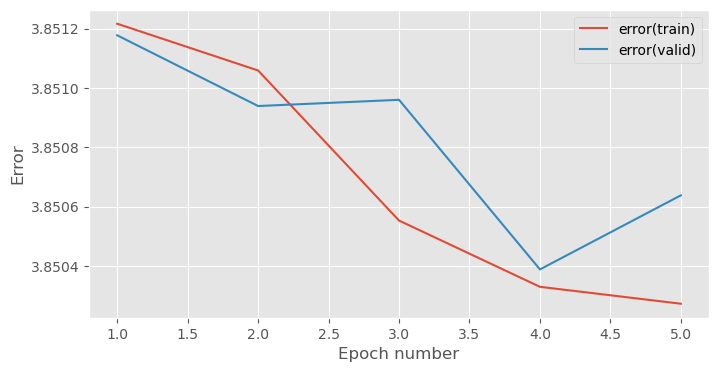

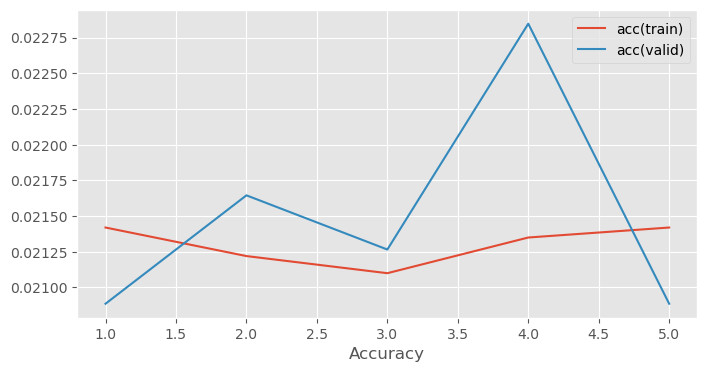

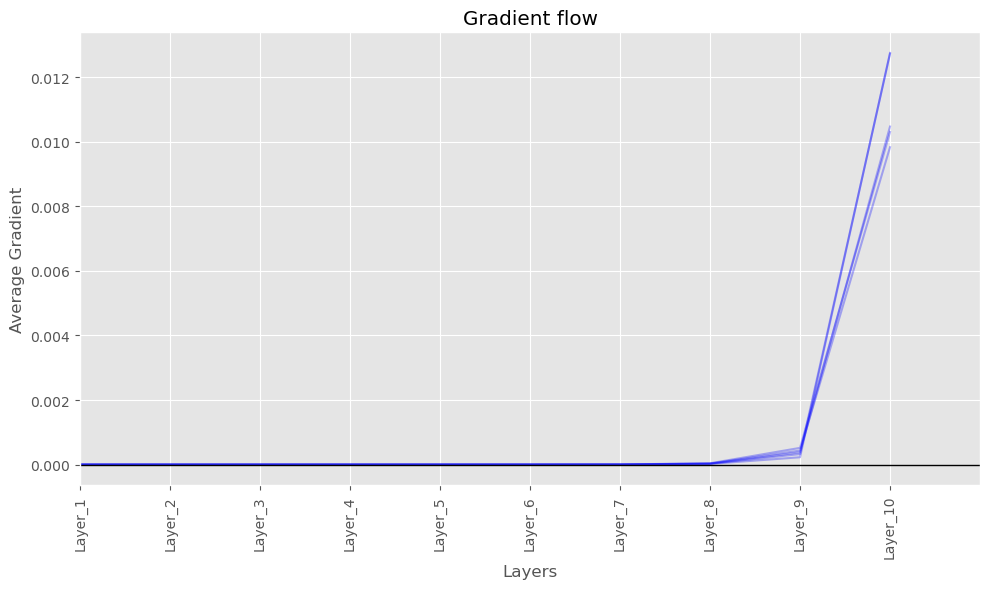

In [7]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

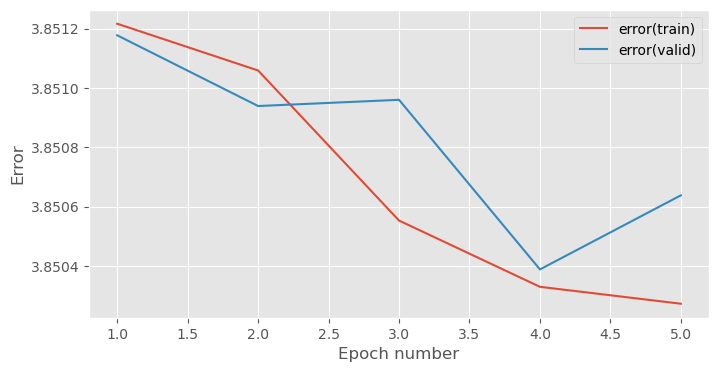

In [8]:
# You can then check the plots like this
fig_1 # The training error plot

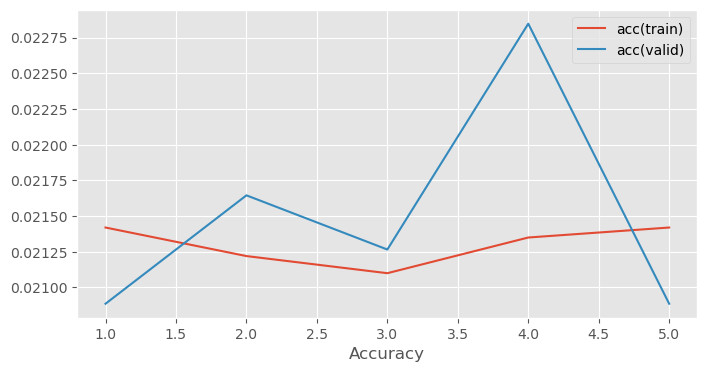

In [9]:
fig_2 # The training accuracy plot

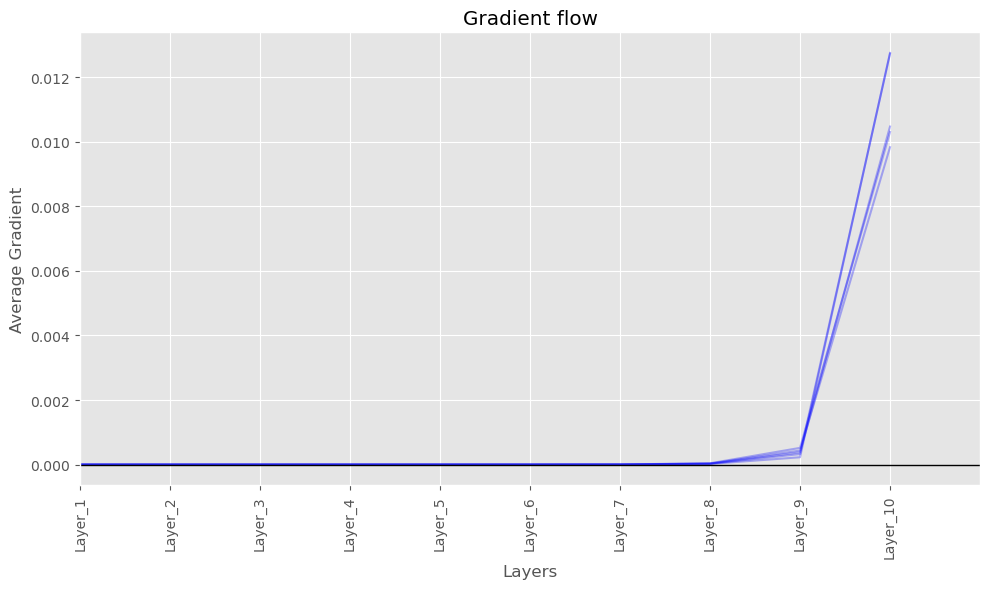

In [10]:
grad_plot # The gradient flow plot

In [ ]:
# Setup common hyperparameters
learning_rate = 0.001
num_epochs = 100  # 根据你的需要调整
stats_interval = 1
input_dim, output_dim = 784, 47
batch_size = 100
seed = 111020

# Set up logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Define the hidden dimensions to test
hidden_dims = [32, 64, 128]

# Store results for all experiments
all_stats = {}
all_keys = {}

# Run experiments for each hidden dimension
for hidden_dim in hidden_dims:
    print(f"\n{'='*60}")
    print(f"Training with {hidden_dim} hidden units")
    print(f"{'='*60}\n")
    
    # Reset data providers for each experiment
    rng = np.random.RandomState(seed)
    train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
    valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)
    
    # Initialize weights
    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)
    
    # Create model with ONE hidden layer (for width experiment)
    model = MultipleLayerModel([
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init),
        ReluLayer(),
        AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
    ])
    
    error = CrossEntropySoftmaxError()
    learning_rule = AdamLearningRule(learning_rate=learning_rate)
    
    # Set up data monitors
    data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}
    
    # Train the model
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, 
        data_monitors, notebook=True
    )
    
    stats, keys, run_time = optimiser.train(
        num_epochs=num_epochs, 
        stats_interval=stats_interval
    )
    
    # Store results
    all_stats[hidden_dim] = stats
    all_keys[hidden_dim] = keys
    
    print(f"\nCompleted training with {hidden_dim} hidden units")
    print(f"Final validation accuracy: {stats[-1, keys['acc(valid)']]:.3f}")
    print(f"Final training error: {stats[-1, keys['error(train)']]:.3f}")
    print(f"Final validation error: {stats[-1, keys['error(valid)']]:.3f}")


Training with 32 hidden units

KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 15.6s to complete
    error(train)=1.23e+00, acc(train)=6.58e-01, error(valid)=1.24e+00, acc(valid)=6.55e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 24: 3.5s to complete
    error(train)=4.57e-01, acc(train)=8.49e-01, error(valid)=5.87e-01, acc(valid)=8.16e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 25: 2.4s to complete
    error(train)=4.53e-01, acc(train)=8.51e-01, error(valid)=5.86e-01, acc(valid)=8.16e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
# Create Figure 2 - Width comparison plots

# Define colors for different widths
colors = {32: 'blue', 64: 'green', 128: 'red'}
epochs = np.arange(1, all_stats[32].shape[0]) * stats_interval

# Create error curves (Figure 2b)
fig_error = plt.figure(figsize=(10, 6))
ax_error = fig_error.add_subplot(111)

for hidden_dim in hidden_dims:
    stats = all_stats[hidden_dim]
    keys = all_keys[hidden_dim]
    color = colors[hidden_dim]
    
    # Plot training error (solid line)
    ax_error.plot(epochs, stats[1:, keys['error(train)']], 
                  color=color, linestyle='-', linewidth=2,
                  label=f'{hidden_dim} units (train)')
    
    # Plot validation error (dashed line)
    ax_error.plot(epochs, stats[1:, keys['error(valid)']], 
                  color=color, linestyle='--', linewidth=2,
                  label=f'{hidden_dim} units (valid)')

ax_error.set_xlabel('Epoch number', fontsize=12)
ax_error.set_ylabel('Cross-entropy Error', fontsize=12)
ax_error.legend(loc='best', fontsize=10)
ax_error.set_title('Error by Epoch for Different Network Widths')
ax_error.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/huez/mlpractical/report/figures/empty_error_curve_width.png', dpi=300, bbox_inches='tight')
plt.show()

# Create accuracy curves (Figure 2a)
fig_acc = plt.figure(figsize=(10, 6))
ax_acc = fig_acc.add_subplot(111)

for hidden_dim in hidden_dims:
    stats = all_stats[hidden_dim]
    keys = all_keys[hidden_dim]
    color = colors[hidden_dim]
    
    # Plot training accuracy (solid line)
    ax_acc.plot(epochs, stats[1:, keys['acc(train)']], 
                color=color, linestyle='-', linewidth=2,
                label=f'{hidden_dim} units (train)')
    
    # Plot validation accuracy (dashed line)
    ax_acc.plot(epochs, stats[1:, keys['acc(valid)']], 
                color=color, linestyle='--', linewidth=2,
                label=f'{hidden_dim} units (valid)')

ax_acc.set_xlabel('Epoch number', fontsize=12)
ax_acc.set_ylabel('Classification Accuracy', fontsize=12)
ax_acc.legend(loc='best', fontsize=10)
ax_acc.set_title('Accuracy by Epoch for Different Network Widths')
ax_acc.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/huez/mlpractical/report/figures/empty_acc_curve_width.png', dpi=300, bbox_inches='tight')
plt.show()